## 1. Problem Definition & Data Collection

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

data = pd.read_csv('../data/phone-details/cleaned_my_dataset.csv')
print(f"Initial dataset: {data.shape[0]} rows, {data.shape[1]} columns")
data.head()

Initial dataset: 1039 rows, 7 columns


,Price,Condition,Brand,RAM,Memory,SIM Support,Network
0,35000,Used,Samsung,6,128,Dual SIM,5G
1,102000,Used,Apple,9,128,Single SIM,5G
2,14000,Used,Samsung,4,64,Dual SIM,4G
3,18000,Used,Samsung,4,64,Dual SIM,4G
4,126000,Used,Apple,6,256,Dual VoLTE,5G


## 2. Data Loading & Preprocessing

In [12]:
print(f"Dataset Shape: {data.shape}")
print(f"\nDataset Info:")
print(f"  - Total samples: {len(data)}")
print(f"  - Features: {data.columns.tolist()}")
print(f"\nFirst few rows:")
data.head()

Dataset Shape: (1039, 7)

Dataset Info:
  - Total samples: 1039
  - Features: ['Price', 'Condition', 'Brand', 'RAM', 'Memory', 'SIM Support', 'Network']

First few rows:


,Price,Condition,Brand,RAM,Memory,SIM Support,Network
0,35000,Used,Samsung,6,128,Dual SIM,5G
1,102000,Used,Apple,9,128,Single SIM,5G
2,14000,Used,Samsung,4,64,Dual SIM,4G
3,18000,Used,Samsung,4,64,Dual SIM,4G
4,126000,Used,Apple,6,256,Dual VoLTE,5G


In [16]:
# Prepare features and target
X = data.drop(columns=['Price'], errors='ignore')
y = data['Price']

# One-hot encode model column
X_encoded = pd.get_dummies(X, columns=['Brand'], drop_first=True)

print(f"Feature Matrix Shape: {X_encoded.shape}")
print(f"Target Variable Shape: {y.shape}")
print(f"\nFeatures after encoding: {X_encoded.shape[1]}")
print(f"\nFeature names:")
for i, col in enumerate(X_encoded.columns, 1):
    print(f"  {i:2d}. {col}")

Feature Matrix Shape: (1039, 13)
Target Variable Shape: (1039,)

Features after encoding: 13

Feature names:
   1. Condition
   2. RAM
   3. Memory
   4. SIM Support
   5. Network
   6. Brand_Google
   7. Brand_Honor
   8. Brand_Huawei
   9. Brand_Oppo
  10. Brand_Other brand
  11. Brand_Samsung
  12. Brand_Vivo
  13. Brand_Xiaomi


In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Data Split:")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(data)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(data)*100:.1f}%)")
print(f"\nTraining price range: Rs. {y_train.min():,.0f} - Rs. {y_train.max():,.0f}")
print(f"Testing price range:  Rs. {y_test.min():,.0f} - Rs. {y_test.max():,.0f}")

Data Split:
Training set: 831 samples (80.0%)
Testing set:  208 samples (20.0%)

Training price range: Rs. 1,200 - Rs. 442,000
Testing price range:  Rs. 2,700 - Rs. 442,000


In [24]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Test different number of trees
print("Testing different number of trees...")
print("=" * 60)

n_estimators_range = [10, 25, 50, 100, 150, 200]
results_trees = []

for n_trees in n_estimators_range:
    rf = RandomForestRegressor(
        n_estimators=n_trees,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    train_score = rf.score(X_train, y_train)
    test_score = rf.score(X_test, y_test)

    results_trees.append({
        'n_estimators': n_trees,
        'train_r2': train_score,
        'test_r2': test_score,
        'gap': train_score - test_score
    })

    print(f"Trees: {n_trees:3d} | Train R²: {train_score:.4f} | Test R²: {test_score:.4f} | Gap: {train_score-test_score:.4f}")

results_trees_df = pd.DataFrame(results_trees)
print("\n✓ Tree count analysis complete")
display(results_trees_df)

Testing different number of trees...


ValueError: could not convert string to float: 'Used'

NameError: name 'results_trees_df' is not defined

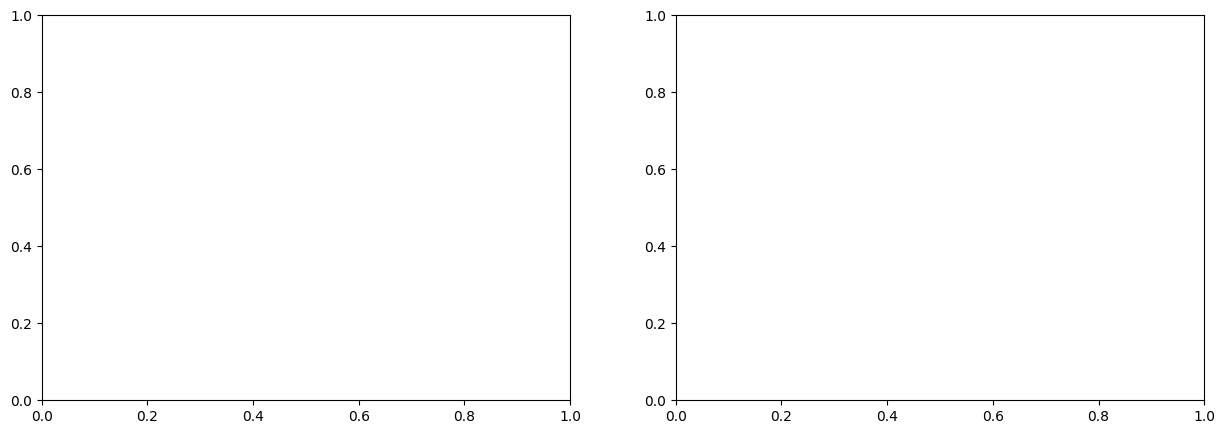

In [23]:
# Visualize n_estimators impact
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: R² scores
axes[0].plot(results_trees_df['n_estimators'], results_trees_df['train_r2'],
             marker='o', label='Training R²', linewidth=2)
axes[0].plot(results_trees_df['n_estimators'], results_trees_df['test_r2'],
             marker='s', label='Test R²', linewidth=2)
axes[0].axvline(x=100, color='red', linestyle='--', alpha=0.5, label='Selected: 100')
axes[0].set_xlabel('Number of Trees (n_estimators)', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Model Performance vs Number of Trees', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Overfitting gap
axes[1].plot(results_trees_df['n_estimators'], results_trees_df['gap'],
             marker='D', color='coral', linewidth=2)
axes[1].axvline(x=100, color='red', linestyle='--', alpha=0.5, label='Selected: 100')
axes[1].axhline(y=0.05, color='green', linestyle=':', alpha=0.5, label='5% threshold')
axes[1].set_xlabel('Number of Trees (n_estimators)', fontsize=12)
axes[1].set_ylabel('Overfitting Gap (Train R² - Test R²)', fontsize=12)
axes[1].set_title('Overfitting Gap vs Number of Trees', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Analysis: 100 trees provides good balance between performance and efficiency")
print(f"   - Test R² at 100 trees: {results_trees_df[results_trees_df['n_estimators']==100]['test_r2'].values[0]:.4f}")
print(f"   - Minimal improvement beyond 100 trees")